Iter  xl         xu         xr         f(xr)      ea (%)    
------------------------------------------------------------
1     0.500000   2.000000   1.250000   -4.314397  100.000000
2     1.250000   2.000000   1.625000   -3.339704  23.076923 
3     1.625000   2.000000   1.812500   -0.524399  10.344828 
4     1.812500   2.000000   1.906250   1.868290   4.918033  
5     1.812500   1.906250   1.859375   0.575210   2.521008  
6     1.812500   1.859375   1.835938   0.002394   1.276596  
7     1.812500   1.835938   1.824219   -0.266613  0.642398  
8     1.824219   1.835938   1.830078   -0.133530  0.320171  
9     1.830078   1.835938   1.833008   -0.065925  0.159830  
10    1.833008   1.835938   1.834473   -0.031855  0.079851  
11    1.834473   1.835938   1.835205   -0.014753  0.039910  
12    1.835205   1.835938   1.835571   -0.006185  0.019951  
13    1.835571   1.835938   1.835754   -0.001897  0.009974  
14    1.835754   1.835938   1.835846   0.000248   0.004987  
15    1.835754   1.83584

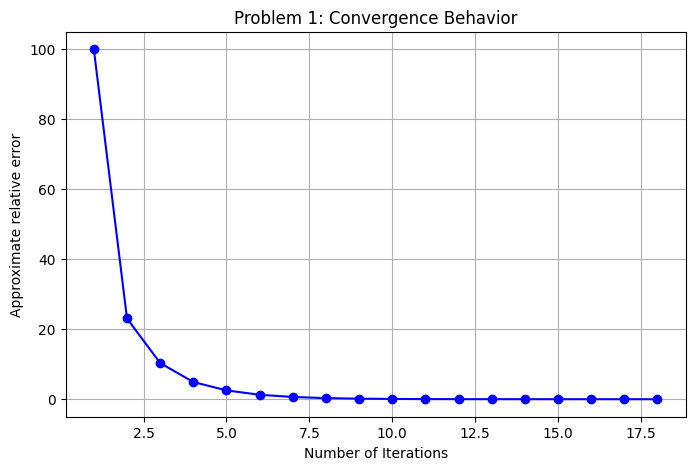

In [16]:
#Problem 1
import numpy as np
import matplotlib.pyplot as plt

def f1(x):
    return x**5 - 4*x**3 + 2*x**2 - np.log(x + 2) - 1.5

def bisection_problem1(xl, xu, tol_sig_figs=5):
    target_error = 0.5 * 10**(2 - tol_sig_figs)

    xr_old = 0
    errors = []
    iterations = []

    print(f"{'Iter':<5} {'xl':<10} {'xu':<10} {'xr':<10} {'f(xr)':<10} {'ea (%)':<10}")
    print("-" * 60)

    for i in range(1, 100):
        xr = (xl + xu) / 2
        fxr = f1(xr)

        # Approximate relative error
        ea = abs((xr - xr_old) / xr) * 100 if i > 1 else 100
        errors.append(ea)
        iterations.append(i)

        print(f"{i:<5} {xl:<10.6f} {xu:<10.6f} {xr:<10.6f} {fxr:<10.6f} {ea:<10.6f}")

        if ea < target_error or abs(fxr) < 1e-7:
            break

        if f1(xl) * fxr < 0:
            xu = xr
        else:
            xl = xr
        xr_old = xr

    return iterations, errors

# Execution
iter1, err1 = bisection_problem1(0.5, 2.0)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(iter1, err1, marker='o', color='b')
plt.yscale('linear') # Log scale helps visualize convergence
plt.title('Problem 1: Convergence Behavior')
plt.xlabel('Number of Iterations')
plt.ylabel('Approximate relative error')
plt.grid(True)
plt.show()

Iter  xl         xu         xr         f(xr)      ea (%)    
------------------------------------------------------------
1     0.300000   1.500000   0.900000   0.014914   100.000000
2     0.300000   0.900000   0.600000   -0.522115  50.000000 
3     0.600000   0.900000   0.750000   -0.226943  20.000000 
4     0.750000   0.900000   0.825000   -0.101456  9.090909  
5     0.825000   0.900000   0.862500   -0.042310  4.347826  
6     0.862500   0.900000   0.881250   -0.013477  2.127660  
7     0.881250   0.900000   0.890625   0.000772   1.052632  
8     0.881250   0.890625   0.885938   -0.006339  0.529101  
9     0.885938   0.890625   0.888281   -0.002780  0.263852  

Stopping criterion reached: ea = 0.2639%


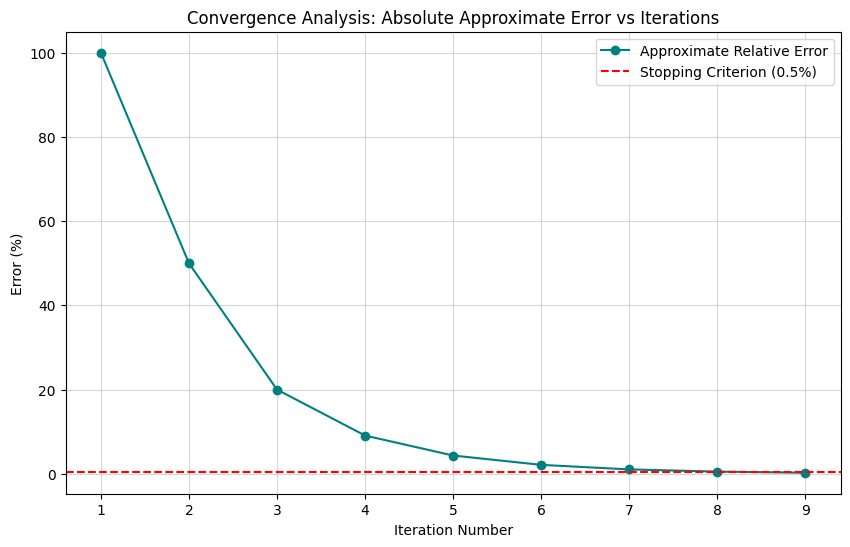

In [17]:
#Problem 2
import numpy as np
import matplotlib.pyplot as plt

def f2(y):
    Q, g, L = 1.2, 9.81, 15
    A = 2*y + y**2
    P = 2 + 2 * np.sqrt(1 + y**2)
    return np.sqrt(2*g / L) * (A / P)**(1.5) - Q / A

def bisection_problem2(xl, xu, nmax=12, es=0.5):
    xr_old = 0
    errors = []
    iterations = []

    print(f"{'Iter':<5} {'xl':<10} {'xu':<10} {'xr':<10} {'f(xr)':<10} {'ea (%)':<10}")
    print("-" * 60)

    for i in range(1, nmax+1):
        xr = (xl + xu) / 2
        fxr = f2(xr)

        # Approximate relative error
        ea = abs((xr - xr_old) / xr) * 100 if i > 1 else 100
        errors.append(ea)
        iterations.append(i)

        print(f"{i:<5} {xl:<10.6f} {xu:<10.6f} {xr:<10.6f} {fxr:<10.6f} {ea:<10.6f}")

        if ea <= es:
            print(f"\nStopping criterion reached: ea = {ea:.4f}%")
            break

        if f2(xl) * f2(xr) < 0:
            xu = xr
        else:
            xl = xr
        xr_old = xr

    return iterations, errors

# Execution
iter2, err2 = bisection_problem2(0.3, 1.5)

# Plotting Error Convergence
plt.figure(figsize=(10, 6))
plt.plot(iter2, err2, 'o-', color='teal', label='Approximate Relative Error')
plt.axhline(y=0.5, color='r', linestyle='--', label='Stopping Criterion (0.5%)')
plt.yscale('linear')
plt.title('Convergence Analysis: Absolute Approximate Error vs Iterations')
plt.xlabel('Iteration Number')
plt.ylabel('Error (%)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()